In [1]:
%matplotlib inline
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_context('notebook')

import os

os.getcwd()

'C:\\Users\\nasakyi\\Desktop\\Thesis'

In [253]:
Data0 = pd.read_csv('C:/Users/nasakyi/Desktop/Thesis/VaccManDat.csv')
Data1 = Data0.sample(n=1000, random_state=123)
print(Data1)

       VaccManDat.VACC_STATUS  VaccManDat.GENDER  XG1  XG2  VaccManDat.RACE  \
27365                       0                  1    1    0                1   
36977                       1                  2    0    1                1   
40387                       0                  1    1    0                1   
37402                       0                  1    1    0                1   
17371                       0                  1    1    0                1   
...                       ...                ...  ...  ...              ...   
34323                       0                  2    0    1                1   
33936                       0                  1    1    0                1   
41234                       0                  1    1    0                3   
38892                       1                  2    0    1                1   
26644                       0                  1    1    0                3   

       VaccManDat.HISPANIC  VaccManDat.EDUC  XE1  X

In [86]:
#Outputting the columns for the categorical predictors

X = Data1[['XG1','XE1', 'XE2', 'XE3','XIN1','XIN2']]
X.head()

,XG1,XE1,XE2,XE3,XIN1,XIN2
27365,1,0,0,0,0,0
36977,0,0,0,0,0,0
40387,1,0,0,0,0,0
37402,1,0,0,1,0,0
17371,1,0,0,0,0,0


In [87]:
# Outputting the binary response vector, VaccManDat.VACC_STATUS

vacc=Data1.iloc[:,0]
print(vacc)

27365    0
36977    1
40387    0
37402    0
17371    0
        ..
34323    0
33936    0
41234    0
38892    1
26644    0
Name: VaccManDat.VACC_STATUS, Length: 1000, dtype: int64


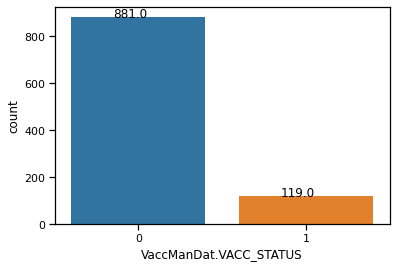

In [22]:
# A Count Plot Distribution of the Vaccination Status

ax = sns.countplot(x = vacc)
for p in ax.patches:
   ax.annotate('{:.1f}'.format(p.get_height()), (p.get_x()+0.25, p.get_height()+0.01))

plt.show()

In [27]:
# Chi-squared Test of Independence Between Vaccine Status and Gender
from scipy.stats import chi2_contingency
stat, p, dof, expected = chi2_contingency(Data1.iloc[:,1],Data1.iloc[:,3])
print('stat=%.3f, p=%.3f' % (stat, p))
if p > 0.05:
	print('Probably independent')
else:
	print('Probably dependent')

stat=0.000, p=1.000
Probably independent


In [28]:
# Chi-squared Test of Independence Between Vaccine Status and Education Level
from scipy.stats import chi2_contingency
stat, p, dof, expected = chi2_contingency(Data1.iloc[:,1],Data1.iloc[:,7])
print('stat=%.3f, p=%.3f' % (stat, p))
if p > 0.05:
	print('Probably independent')
else:
	print('Probably dependent')

stat=0.000, p=1.000
Probably independent


In [29]:
# Chi-squared Test of Independence Between Vaccine Status and Income Level
from scipy.stats import chi2_contingency
stat, p, dof, expected = chi2_contingency(Data1.iloc[:,1],Data1.iloc[:,12])
print('stat=%.3f, p=%.3f' % (stat, p))
if p > 0.05:
	print('Probably independent')
else:
	print('Probably dependent')

stat=0.000, p=1.000
Probably independent


In [7]:
#---Model I: Homogeneity among all 1000 observations across all regions----# 

In [66]:
import pystan                                                                                                                                        
import pandas as pd                                                                                  
import numpy as np 

code = """     

data {
  int<lower=0> N;               //the number of training observations    
  int<lower=0> K;               //the number of features/covariates    
  matrix[N,K] X;               //the model (features/covariates) matrix
  
  
  int y[N];                    //the response     
}


parameters {
  real alpha;                 //intercept
  vector[K] beta;            //the regression coefficients                                                        

} 

transformed parameters {                                                                             
  vector[N] lpred; 
  vector[N] pi_hat;
  
  for (i in 1:N){
  lpred[i] = alpha+X[i]*beta;   // logit=P(y=1)=pi 
  pi_hat[i] = exp(lpred[i])/(1 + exp(lpred[i]));
 }
}


model {

   //--------------priors----------------------------
  alpha ~ cauchy(0,10);       //prior for the intercept following Gelman 2008                              
                                                                                                     
  for(i in 1:K)               // K=1, if one regressor                                                                                   
    beta[i] ~ student_t(1, 0, 0.03);        
    
    
  //------------likelihood-----------                                                 
  y ~ bernoulli_logit(lpred);

}


"""

In [67]:
data = {
    'N':len(vacc),
    'K':6,
    'X':X,
    'y':vacc,
}

In [68]:
SM = pystan.StanModel(model_code=code)

INFO:pystan:COMPILING THE C++ CODE FOR MODEL anon_model_07915228d8d4d4110c2b476607c54bb0 NOW.


In [69]:
fit = SM.sampling(data=data, iter=1000, seed=1234)

To run all diagnostics call pystan.check_hmc_diagnostics(fit)


In [70]:
print(fit)

Inference for Stan model: anon_model_07915228d8d4d4110c2b476607c54bb0.
4 chains, each with iter=1000; warmup=500; thin=1; 
post-warmup draws per chain=500, total post-warmup draws=2000.

               mean se_mean     sd   2.5%     25%    50%     75%  97.5%  n_eff   Rhat
alpha         -2.45  9.3e-3   0.18  -2.83   -2.56  -2.44   -2.32  -2.12    365   1.01
beta[1]       -0.04  5.3e-3   0.11  -0.34   -0.06  -0.01 10.0e-3   0.09    413    1.0
beta[2]        0.02    0.01   0.17  -0.17   -0.02 4.5e-3    0.04   0.39    224   1.02
beta[3]        0.37    0.03   0.43  -0.06    0.01   0.16    0.73   1.33    205   1.02
beta[4]        0.85    0.01   0.25   0.33    0.68   0.85    1.02   1.34    352   1.01
beta[5]         0.1    0.01    0.2  -0.08 -5.2e-3   0.02    0.12   0.72    188   1.01
beta[6]        0.26    0.02   0.29  -0.05    0.02   0.16    0.48   0.88    255   1.01
lpred[1]      -2.49  9.8e-3   0.19  -2.87   -2.62  -2.48   -2.36  -2.15    367   1.01
lpred[2]      -2.45  9.3e-3   0.18  -2.

In [71]:
#---Obtaining Distribution and Trace Plots for the Convergence Diagnostics of the Posteriors---#

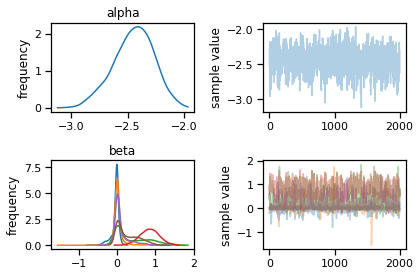

In [72]:
fit.plot(pars=['alpha', 'beta'])
plt.tight_layout()

In [144]:
# Plotting Change in Odds Ratios For Each Predictor

cffs = fit['beta'].mean(axis=0)
cffs

odds_ratio = np.exp(cffs)
odds_ratio

array([0.95760248, 1.02110154, 1.45469051, 2.32982487, 1.10987807,
       1.30342528])

In [145]:
delta_odds = odds_ratio - 1
delta_odds

array([-0.04239752,  0.02110154,  0.45469051,  1.32982487,  0.10987807,
        0.30342528])

In [155]:
# xvals = np.arange(start=1, stop=7, step=1)
xvals = ["Gender", "Edu 1", "Edu 2", "Edu 3", "Inc 1", "Inc 2"]

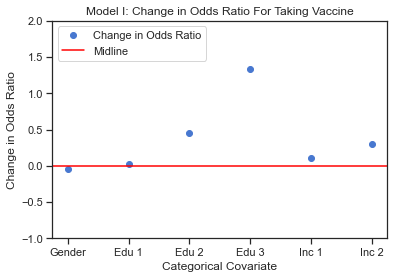

In [214]:
plt.plot(xvals, delta_odds,'o', label="Change in Odds Ratio")
plt.ylim(-1, 2)
plt.axhline(y=0, color='red', label="Midline")
plt.legend(loc="upper left")
plt.title("Model I: Change in Odds Ratio For Taking Vaccine")
plt.xlabel("Categorical Covariate")
plt.ylabel("Change in Odds Ratio")
plt.show()


In [88]:
#---Model II: Considering A Varying Intercepts (Based on Regions) and Fixed Slopes-----#

#We First obtain the column for the regional codes as follows:

reg=Data1.iloc[:,17].astype('category')
print(reg)

27365    5
36977    5
40387    3
37402    2
17371    2
        ..
34323    7
33936    1
41234    3
38892    3
26644    7
Name: REGCODE, Length: 1000, dtype: category
Categories (8, int64): [1, 2, 3, 4, 5, 6, 7, 8]


In [89]:
varint_code = """     

data {
  int<lower=0> J;
  int<lower=0> N;               //the number of training observations    
  int<lower=0> K;               //the number of features/covariates  
  int<lower=1,upper=8> Z[N];    //group level predictor (regional codes)
  matrix[N,K] X;               //the model (features/covariates) matrix
  
  int y[N];                    //the response     
}


parameters {
  vector[J] alpha;
  //real alpha;                 //intercept
  vector[K] beta;            //the regression parameters                                                        

} 

transformed parameters {                                                                             
  vector[N] lpred; 
  vector[N] pi_hat;
  //linpred = alpha[Z]+X*beta;   // logit=P(y=1)=pi  
  
  for (i in 1:N){
    lpred[i] = alpha[Z[i]] + X[i,:] * beta;
    pi_hat[i] = exp(lpred[i])/(1 + exp(lpred[i]));
  }
}


model {

   //--------------priors----------------------------
  alpha ~ cauchy(0,10);       //prior for the intercept following Gelman 2008                              
                                                                                                     
  for(j in 1:K)               // K=1, if one regressor                                                                                   
    beta[j] ~ student_t(1, 0, 0.03);                                                                 
    

 //------------likelihood-----------                                                 
  //y ~ bernoulli_logit(alpha[Z]+X*beta);
  y ~ bernoulli_logit(lpred);

}


"""


In [90]:
varint_data = {
    'J':len(pd.unique(Data1['REGCODE'])),
    'N':len(vacc),
    'K':6,
    'X':X,
    'y':vacc,
    'Z':reg,
}

print(varint_data)

{'J': 8, 'N': 1000, 'K': 6, 'X':        XG1  XE1  XE2  XE3  XIN1  XIN2
27365    1    0    0    0     0     0
36977    0    0    0    0     0     0
40387    1    0    0    0     0     0
37402    1    0    0    1     0     0
17371    1    0    0    0     0     0
...    ...  ...  ...  ...   ...   ...
34323    0    0    0    1     0     0
33936    1    0    0    0     0     0
41234    1    0    0    0     0     0
38892    0    0    0    1     0     0
26644    1    0    0    0     0     0

[1000 rows x 6 columns], 'y': 27365    0
36977    1
40387    0
37402    0
17371    0
        ..
34323    0
33936    0
41234    0
38892    1
26644    0
Name: VaccManDat.VACC_STATUS, Length: 1000, dtype: int64, 'Z': 27365    5
36977    5
40387    3
37402    2
17371    2
        ..
34323    7
33936    1
41234    3
38892    3
26644    7
Name: REGCODE, Length: 1000, dtype: category
Categories (8, int64): [1, 2, 3, 4, 5, 6, 7, 8]}


In [91]:
SM_var = pystan.StanModel(model_code=varint_code)

INFO:pystan:COMPILING THE C++ CODE FOR MODEL anon_model_a4d10c5790b1555b1b4d67f066b1356a NOW.


In [92]:
fit_var = SM_var.sampling(data=varint_data, iter=1000, seed=1234)

To run all diagnostics call pystan.check_hmc_diagnostics(fit)


In [93]:
print(fit_var)

Inference for Stan model: anon_model_a4d10c5790b1555b1b4d67f066b1356a.
4 chains, each with iter=1000; warmup=500; thin=1; 
post-warmup draws per chain=500, total post-warmup draws=2000.

               mean se_mean     sd   2.5%     25%    50%    75%  97.5%  n_eff   Rhat
alpha[1]      -1.95    0.01   0.25  -2.47   -2.13  -1.95  -1.78  -1.48    632   1.01
alpha[2]      -3.04    0.01   0.34  -3.78   -3.26  -3.04   -2.8   -2.4    669   1.01
alpha[3]      -2.51    0.01   0.32  -3.15   -2.71   -2.5  -2.28   -1.9    806   1.01
alpha[4]      -2.24    0.01   0.28   -2.8   -2.44  -2.24  -2.04   -1.7    714   1.01
alpha[5]      -2.13    0.01   0.32   -2.8   -2.35  -2.12  -1.91  -1.56    801    1.0
alpha[6]      -2.62    0.01   0.41  -3.49   -2.89  -2.59  -2.32  -1.88   1420    1.0
alpha[7]      -2.76    0.01   0.34  -3.47   -2.99  -2.73  -2.51  -2.12    934    1.0
alpha[8]      -2.82    0.02    0.5  -3.88   -3.14  -2.79  -2.49   -1.9   1104    1.0
beta[1]       -0.05  6.4e-3   0.11  -0.36   -0.0

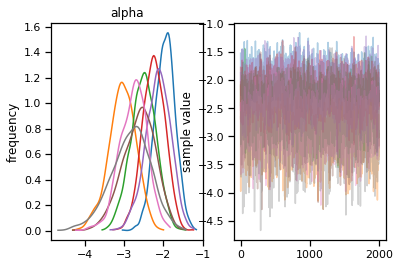

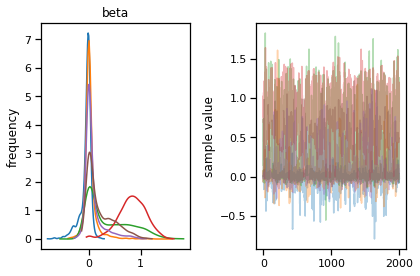

In [79]:
fit_var.plot('alpha')
fit_var.plot('beta')
plt.tight_layout()

<AxesSubplot:>

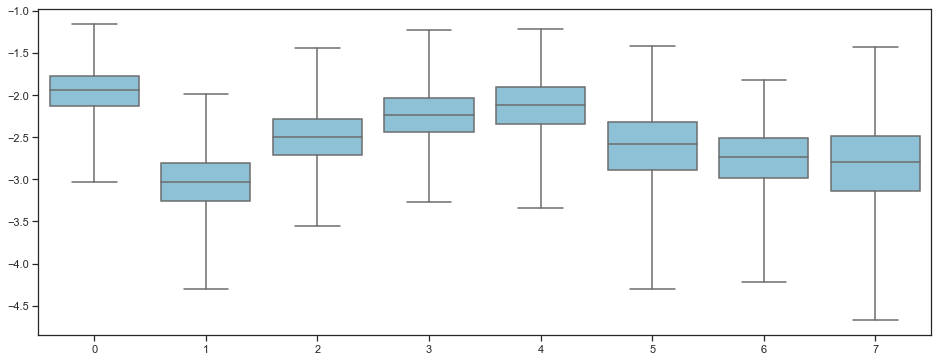

In [80]:
# A Boxplot of the Regional Distribution of observations

a_sample = pd.DataFrame(fit_var['alpha'])

sns.set(style="ticks", palette="muted", color_codes=True)

# Plot the orbital period with horizontal boxes
plt.figure(figsize=(16, 6))
sns.boxplot(data=a_sample, whis=np.inf, color="c")

In [102]:
# The value of the Grand mean of all regional mean effects 
fit_var['beta'].mean()

0.246049982188099

In [278]:
region = Data1['REGCODE'].unique()
reg_sort = [1,2,3,4,5,6,7,8]
mod2_alpha = fit_var['alpha'].mean(axis=0)
mod2_beta = fit_var['beta'].mean(axis=0)
xvals = ["Gender", "Edu 1", "Edu 2", "Edu 3", "Inc 1", "Inc 2"]
odds_ratio2 = np.exp(mod2_beta)
delta_odds2 = odds_ratio2 - 1
delta_odds2

array([-0.04862749,  0.02791883,  0.45304068,  1.30640406,  0.08441957,
        0.23148453])

In [279]:
reg_sort

[1, 2, 3, 4, 5, 6, 7, 8]

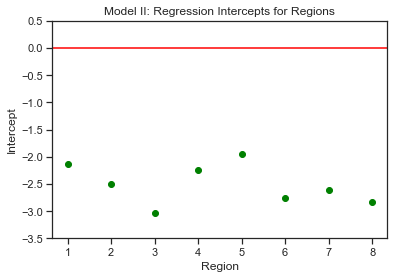

In [206]:
# Plot of Intercepts Against Regions: Model II
plt.plot(region,mod2_alpha,'o',color='green')
plt.axhline(y=0,color='red')
plt.xlabel("Region")
plt.ylabel("Intercept")
plt.ylim(-3.5, 0.5)
#plt.legend(loc='upper right', [Data1['REGION'].unique])
plt.title("Model II: Regression Intercepts for Regions")
plt.show()

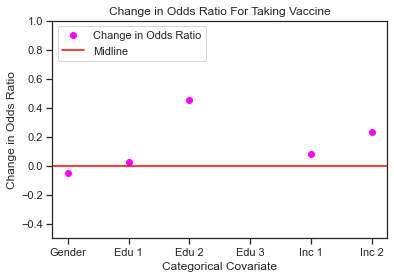

In [213]:
# Plot of Change in Odds Ratios against Predictors: Model II
plt.plot(xvals, delta_odds2,'o', label="Change in Odds Ratio", color='magenta')
plt.ylim(-0.5, 1)
plt.axhline(y=0, color='red', label="Midline")
plt.legend(loc="upper left")
plt.title("Model II: Change in Odds Ratio For Taking Vaccine")
plt.xlabel("Categorical Covariate")
plt.ylabel("Change in Odds Ratio")
plt.show()

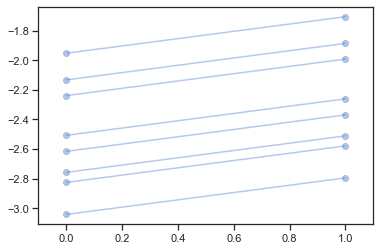

In [82]:
# Plot of the Individual regional mean effects (individual regional intercepts) with same slopes.

xvals = np.arange(2)
bp = fit_var['alpha'].mean(axis=0)
mp = fit_var['beta'].mean()
for bi in bp:
    plt.plot(xvals, mp*xvals + bi, 'bo-', alpha=0.4)
plt.xlim(-0.1,1.1);

In [ ]:
mp*xvals + bi

In [83]:
xvals = np.arange(2)
xvals

array([0, 1])

In [311]:
# Anova Test of Model Intercepts: Model II
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

res = stat()
res.anova_stat(df=Data1, res_var='VaccManDat.VACC_STATUS', anova_model='fit_var')
res.anova_summary

TypeError: 'float' object is not callable

In [2]:
#---Model III: Considering A Varying Slopes (Based on Regions) and Fixed Intercepts-----#

In [57]:
varslope_code = """     

data {
  int<lower=0> J;               //the number of regions
  int<lower=0> N;               //the number of observations    
  int<lower=0> K;               //the number of features/covariates  
  int<lower=1,upper=J> Z[N];    //group level predictor (regional codes)
  matrix[N,K] X;                  //the model (features/covariates) matrix
  
  int y[N];                     //the response     
}


parameters {
  //vector[K] alpha;
  real alpha;                 //intercept
  matrix[K,J] beta;            //the regression coefficients                                                        

} 

transformed parameters {                                                                             
  vector[N] lpred; 
  vector[N] pi_hat;
  //linpred = alpha+X*beta[Z];   // logit=P(y=1)=pi  
  
  for (i in 1:N) {
      lpred[i] = alpha + X[i] * beta[:,Z[i]];
      pi_hat[i] = exp(lpred[i])/(1 + exp(lpred[i])); 
  }
}


model {

   //--------------priors----------------------------
  alpha ~ cauchy(0,10);       //prior for the intercept following Gelman 2008                              
                                                                                                     
  for(j in 1:K)               // K=1, if one regressor                                                                                   
    beta[j] ~ student_t(1, 0, 0.03);                                                                 
    

 //------------likelihood-----------                                                 
  //y ~ bernoulli_logit(alpha+X*beta[Z]);
  y ~ bernoulli_logit(lpred);

}


"""

In [58]:
varslope_data = {
    'J':len(pd.unique(Data1['REGCODE'])),
    'N':len(vacc),
    'K':6,
    'X':X, # Based on Education Level 1
    'y':vacc,
    'Z':reg, # Stan counts starting at 1
}

In [59]:
SM_varslope = pystan.StanModel(model_code=varslope_code)

INFO:pystan:COMPILING THE C++ CODE FOR MODEL anon_model_445cd34050bdbb480d2695df89a45d34 NOW.


In [60]:
fit_varslope = SM_varslope.sampling(data=varslope_data, iter=1000, seed=1234)

To run all diagnostics call pystan.check_hmc_diagnostics(fit)


In [61]:
print(fit_varslope)

Inference for Stan model: anon_model_445cd34050bdbb480d2695df89a45d34.
4 chains, each with iter=1000; warmup=500; thin=1; 
post-warmup draws per chain=500, total post-warmup draws=2000.

                mean se_mean     sd   2.5%      25%     50%    75%  97.5%  n_eff   Rhat
alpha           -2.1  3.4e-3   0.12  -2.34    -2.18   -2.11  -2.03  -1.87   1167    1.0
beta[1,1]       0.01  3.2e-3    0.1  -0.15    -0.02  5.4e-3   0.04   0.27    947    1.0
beta[2,1]       0.02  9.2e-3   0.15  -0.22    -0.02  4.4e-3   0.04   0.34    268   1.01
beta[3,1]       0.05  9.1e-3   0.18  -0.16    -0.02  7.7e-3   0.05   0.65    403   1.02
beta[4,1]       0.84    0.03    0.5  -0.02     0.49    0.91    1.2   1.68    343   1.01
beta[5,1]       0.06    0.02   0.24  -0.12    -0.02  9.4e-3   0.05   0.78    230   1.01
beta[6,1]       0.05    0.01   0.19  -0.15    -0.02  6.7e-3   0.05   0.55    290   1.01
beta[1,2]      -0.02  5.8e-3   0.13  -0.38    -0.03 -4.5e-3   0.02   0.17    540   1.01
beta[2,2]      -0.05 

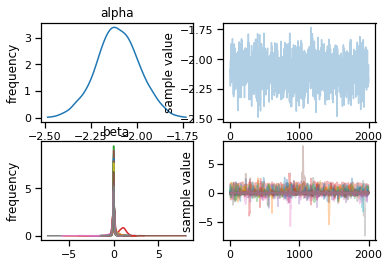

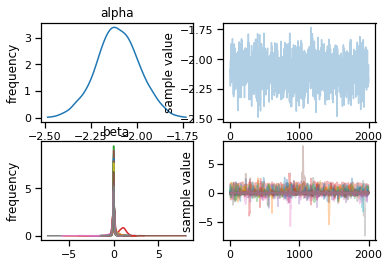

In [62]:
fit_varslope.plot(pars=['alpha', 'beta'])

In [ ]:
# We need a code to plot estimated odds ratios (exp(beta)) against the categorical variables

In [216]:
pars = fit_varslope['beta'].mean(axis=0)
OR = np.exp(pars)
delta_OR = OR - 1
delta_OR

array([[ 1.46088722e-02, -2.37130052e-02, -7.24565129e-03,
        -2.27874285e-02,  9.39266085e-04,  2.17132600e-03,
        -9.44857418e-02, -2.66233172e-02],
       [ 1.58809537e-02, -5.17012886e-02,  2.19402014e-02,
        -2.77414972e-02,  1.18667635e-01, -3.34084199e-02,
         5.38914654e-02, -1.08254056e-02],
       [ 5.13876015e-02,  9.48059591e-03,  3.32516051e-02,
         1.06847843e-01, -5.71104333e-03, -1.73477288e-02,
         2.51901767e-02, -3.17873136e-02],
       [ 1.31076751e+00, -6.47497902e-03,  9.51929192e-04,
         1.38936022e-01,  5.13429859e-02,  6.19897816e-02,
         1.20122341e-01,  9.65234060e-03],
       [ 6.65359431e-02,  6.98648605e-03,  3.53565805e-03,
         2.44755318e-02,  4.64153188e-02, -3.04294362e-02,
         2.74616287e-02, -2.90765470e-02],
       [ 5.11437661e-02,  1.07953386e-02,  8.73010848e-02,
         2.62983296e-02,  5.46643961e-02, -1.19408392e-02,
         9.42722830e-02,  2.20390305e-02]])

In [119]:
preds = np.array([[Data1.XG1.unique(), Data1.XE1.unique(), Data1.XE2.unique(), Data1.XE3.unique(), Data1.XIN1.unique(), Data1.XIN2.unique()]])
preds

array([[[1, 0],
        [0, 1],
        [0, 1],
        [0, 1],
        [0, 1],
        [0, 1]]], dtype=int64)

In [262]:
pars


array([[ 0.01450319, -0.02399868, -0.00727203, -0.02305107,  0.00093883,
         0.00216897, -0.09925226, -0.02698414],
       [ 0.01575617, -0.05308573,  0.02170298, -0.02813356,  0.11213837,
        -0.03397923,  0.05248947, -0.01088443],
       [ 0.05011082,  0.00943594,  0.03271073,  0.10151619, -0.00572741,
        -0.01749996,  0.02487813, -0.0323035 ],
       [ 0.83757972, -0.00649603,  0.00095148,  0.13009451,  0.05006838,
         0.0601443 ,  0.11343791,  0.00960605],
       [ 0.06441596,  0.00696219,  0.00352942,  0.02418081,  0.04537034,
        -0.03090202,  0.02709132, -0.02950765],
       [ 0.04987887,  0.01073748,  0.08369856,  0.02595847,  0.05322261,
        -0.0120127 ,  0.09008956,  0.02179968]])

In [263]:
pars_t = np.transpose(pars)
pars_t

array([[ 0.01450319,  0.01575617,  0.05011082,  0.83757972,  0.06441596,
         0.04987887],
       [-0.02399868, -0.05308573,  0.00943594, -0.00649603,  0.00696219,
         0.01073748],
       [-0.00727203,  0.02170298,  0.03271073,  0.00095148,  0.00352942,
         0.08369856],
       [-0.02305107, -0.02813356,  0.10151619,  0.13009451,  0.02418081,
         0.02595847],
       [ 0.00093883,  0.11213837, -0.00572741,  0.05006838,  0.04537034,
         0.05322261],
       [ 0.00216897, -0.03397923, -0.01749996,  0.0601443 , -0.03090202,
        -0.0120127 ],
       [-0.09925226,  0.05248947,  0.02487813,  0.11343791,  0.02709132,
         0.09008956],
       [-0.02698414, -0.01088443, -0.0323035 ,  0.00960605, -0.02950765,
         0.02179968]])

In [266]:
pars_t[0]

array([0.01450319, 0.01575617, 0.05011082, 0.83757972, 0.06441596,
       0.04987887])

In [298]:
col = ['red','yellow','green','purple','pink','orange']

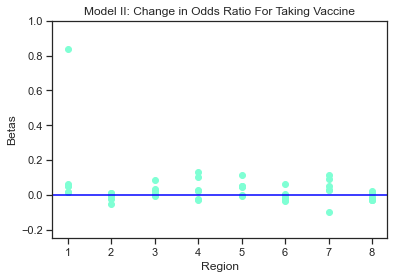

In [309]:
# Plot of Change in Odds Ratios against Predictors: Model II
plt.plot(reg_sort, pars_t,'o', label="Regional Coefficients", color = 'aquamarine')
plt.ylim(-0.25, 1)
plt.axhline(y=0, color='blue', label="Midline")
#plt.legend(loc="upper left")
plt.title("Model II: Change in Odds Ratio For Taking Vaccine")
plt.xlabel("Region")
plt.ylabel("Betas")
plt.show()